# Hierarchical Facility Location Problem

This notebook compares three approaches for the **two-level, globally-inclusive, nested HFLP**:

1. **Simulated Annealing (SA)** – Metropolis-criterion metaheuristic.
2. **Genetic Algorithm (GA)** – population-based evolutionary metaheuristic.
3. **Integer Linear Programming (ILP)** – exact CBC/PuLP solver (used as baseline on small instances).

All algorithms and the problem definition live in `hflp_algorithms.py`.

### Problem Formulation

Following Daskin (1995) and Şahin & Süral (2007), we consider a **two-level, globally-inclusive, nested** HFLP.

**Sets:**
- $I$: demand nodes  
- $J = J'$: candidate sites for Level-1 and Level-2 facilities

**Parameters:**
- $h_i$: demand at node $i$  
- $d_{ij}$: shortest-path distance from demand node $i$ to candidate $j$  
- $p_1, p_2$: number of level-1 and level-2 facilities to open  $(p_2 \le p_1)$

**Objective** (minimize total demand-weighted travel):
$$\min \sum_i \sum_j h_i \, d_{ij} \, Y_{ij} + \sum_i \sum_{j'} h_i \, d_{ij'} \, X_{ij'}$$

with nesting constraint $x_{j'} \le y_{j'}$ (every L2 site must also be open as an L1 site).

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from hflp_algorithms import (
    make_random_graph,
    make_grid_graph,
    make_hflp_instance,
    eval_solution,
    simulated_annealing_hflp,
    solve_hflp_ilp,
    genetic_algorithm_hflp,
    plot_solution,
    plot_convergence_history,
    compare_bar,
)
import hflp_algorithms as hflp

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)
random.seed(42)

# Artificial experiments
### Small Random Graph (20 nodes)

Erdős–Rényi graph, $n=20$, $p_{\text{edge}}=0.3$, Euclidean weights.  
Open $p_1=5$ Level-1 and $p_2=2$ Level-2 facilities.  
The ILP gives the exact optimum on this size.

In [2]:
G_small = make_random_graph(n=20, p=0.3, seed=42)
inst_small = make_hflp_instance(G_small, p1=5, p2=2)

print(f'Graph : {G_small.number_of_nodes()} nodes, {G_small.number_of_edges()} edges')
print(f'p1={inst_small["p1"]}, p2={inst_small["p2"]}')
print(f'Demand: {inst_small["demand"]}')

Graph : 20 nodes, 53 edges
p1=5, p2=2
Demand: [5. 7. 4. 4. 8. 8. 8. 9. 9. 8. 7. 5. 1. 8. 1. 8. 7. 4. 6. 9.]


In [3]:
print('Running SA ...')
t0 = time.time()
sa_lv1_s, sa_lv2_s, sa_cost_s, sa_hist_s = simulated_annealing_hflp(
    inst_small,
    T_init=300.0, alpha=0.997, max_iter=5_000, seed=0, verbose=False
)
sa_time_s = time.time() - t0

print(f'\nSA  best cost : {sa_cost_s:.4f}  ({sa_time_s:.2f}s)')
print(f'    L1 open   : {sorted(sa_lv1_s)}')
print(f'    L2 open   : {sorted(sa_lv2_s)}')

Running SA ...

SA  best cost : 81.9672  (0.25s)
    L1 open   : [4, 6, 7, 13, 14]
    L2 open   : [6, 14]


In [4]:
print('Running GA ...')
t0 = time.time()
ga_lv1_s, ga_lv2_s, ga_cost_s, ga_hist_s = genetic_algorithm_hflp(
    inst_small,
    pop_size=60, max_gen=300,
    tournament_k=3, crossover_prob=0.8, mutation_rate=0.3,
    elitism=True, seed=0, verbose=False
)
ga_time_s = time.time() - t0

print(f'\nGA  best cost : {ga_cost_s:.4f}  ({ga_time_s:.2f}s)')
print(f'    L1 open   : {sorted(ga_lv1_s)}')
print(f'    L2 open   : {sorted(ga_lv2_s)}')

Running GA ...

GA  best cost : 81.9672  (0.92s)
    L1 open   : [4, 6, 7, 13, 14]
    L2 open   : [6, 14]


In [5]:
print('Running ILP ...')
t0 = time.time()
ilp_lv1_s, ilp_lv2_s, ilp_cost_s, ilp_time_s, ilp_status_s = solve_hflp_ilp(inst_small)
ilp_time_s = time.time() - t0

print(f'\nILP status    : {ilp_status_s}')
print(f'ILP best cost : {ilp_cost_s:.4f}  ({ilp_time_s:.2f}s)')
print(f'    L1 open   : {sorted(ilp_lv1_s)}')
print(f'    L2 open   : {sorted(ilp_lv2_s)}')

print(f'\nOptimality gap – SA : {100*(sa_cost_s - ilp_cost_s)/ilp_cost_s:.2f}%')
print(f'Optimality gap – GA : {100*(ga_cost_s - ilp_cost_s)/ilp_cost_s:.2f}%')

Running ILP ...

ILP status    : Optimal
ILP best cost : 81.9672  (0.06s)
    L1 open   : [4, 6, 7, 13, 14]
    L2 open   : [6, 14]

Optimality gap – SA : 0.00%
Optimality gap – GA : 0.00%


### 1.4 Convergence Comparison

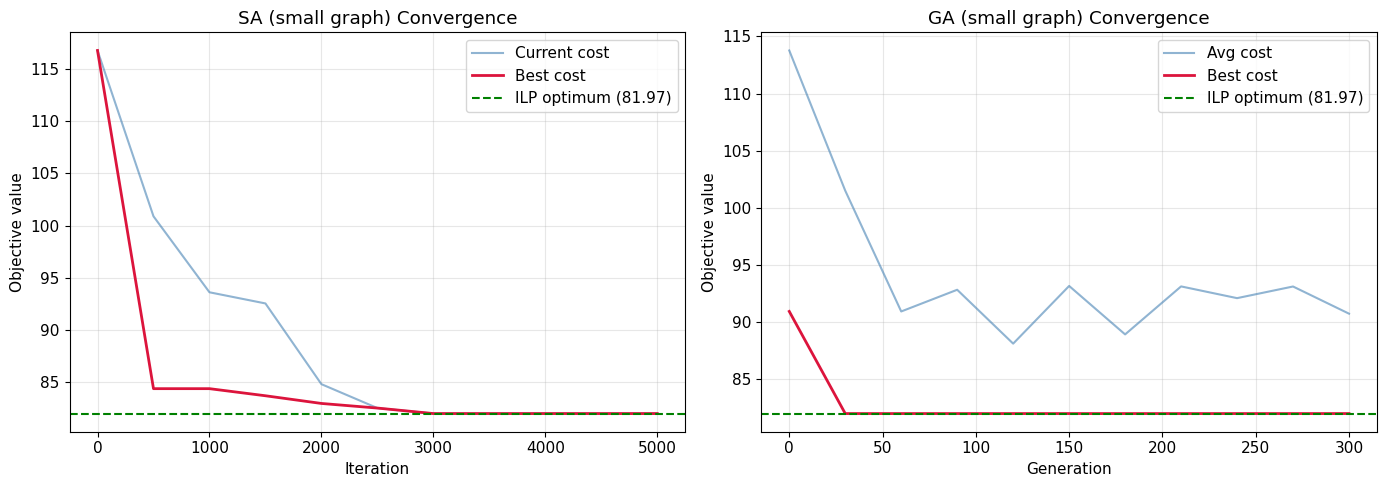

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_convergence_history(sa_hist_s, algo_name='SA (small graph)', ax=axes[0])
# draw ILP optimum as a horizontal reference line
axes[0].axhline(ilp_cost_s, color='green', lw=1.5, ls='--', label=f'ILP optimum ({ilp_cost_s:.2f})')
axes[0].legend()

plot_convergence_history(ga_hist_s, algo_name='GA (small graph)', ax=axes[1])
axes[1].axhline(ilp_cost_s, color='green', lw=1.5, ls='--', label=f'ILP optimum ({ilp_cost_s:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

### Larger Random Graph (400 nodes)

Erdős–Rényi graph, $n=400$, $p_{\text{edge}}=0.2$, Euclidean weights.  
Open $p_1=8$ Level-1 and $p_2=3$ Level-2 facilities.  
ILP is run with a 60-second time limit to get a reference bound.

In [7]:
n_med = 400
G_med = make_random_graph(n=n_med, p=0.2, seed=123)
inst_med = make_hflp_instance(G_med, p1=8, p2=3, demand_seed=99)

print(f'Graph : {G_med.number_of_nodes()} nodes, {G_med.number_of_edges()} edges')
print(f'p1={inst_med["p1"]}, p2={inst_med["p2"]}')

Graph : 400 nodes, 15976 edges
p1=8, p2=3


In [8]:
print('Running SA ...')
t0 = time.time()
sa_lv1_m, sa_lv2_m, sa_cost_m, sa_hist_m = simulated_annealing_hflp(
    inst_med,
    T_init=500.0, alpha=0.9999, max_iter=15_000, seed=0, verbose=False
)
sa_time_m = time.time() - t0
print(f'\nSA  best cost : {sa_cost_m:.4f}  ({sa_time_m:.2f}s)')

Running SA ...

SA  best cost : 975.7984  (16.51s)


In [9]:
print('Running GA ...')
t0 = time.time()
ga_lv1_m, ga_lv2_m, ga_cost_m, ga_hist_m = genetic_algorithm_hflp(
    inst_med,
    pop_size=80, max_gen=500,
    tournament_k=5, crossover_prob=0.8, mutation_rate=0.35,
    elitism=True, seed=0, verbose=False
)
ga_time_m = time.time() - t0
print(f'\nGA  best cost : {ga_cost_m:.4f}  ({ga_time_m:.2f}s)')

Running GA ...


IOStream.flush timed out



GA  best cost : 883.2919  (41.66s)


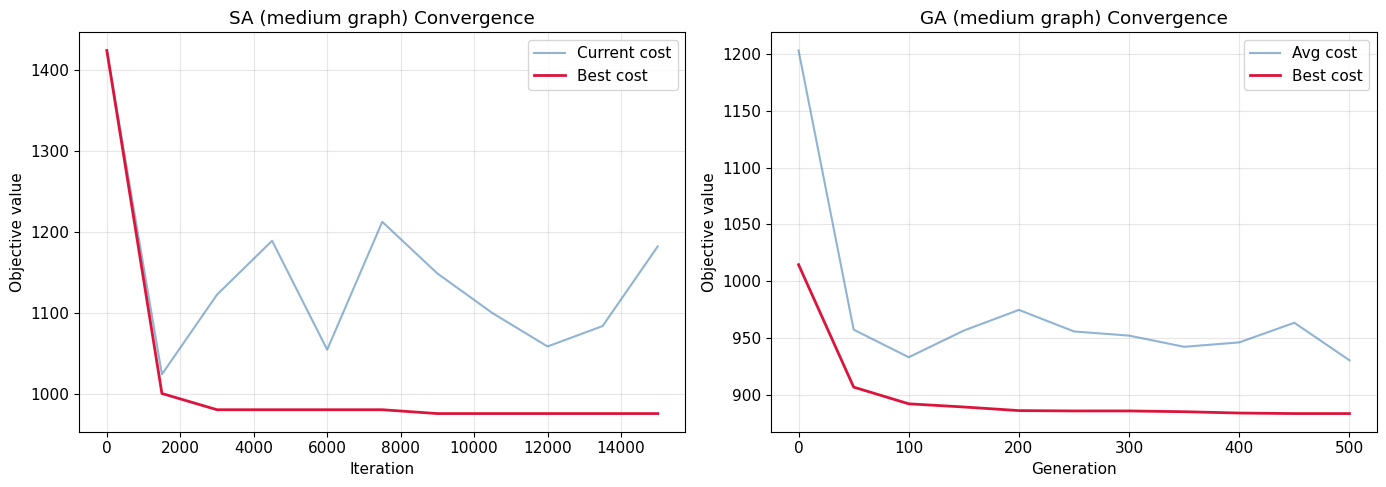

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_convergence_history(sa_hist_m, algo_name='SA (medium graph)', ax=axes[0])
axes[0].legend()

plot_convergence_history(ga_hist_m, algo_name='GA (medium graph)', ax=axes[1])
axes[1].legend()

plt.tight_layout()
plt.show()

---
### Grid Graph (20×20 = 400 nodes)

A 20×20 grid (400 nodes, unit edge weights).  
Open $p_1=10$ Level-1 and $p_2=2$ Level-2 facilities.  
ILP is intractable at this scale; SA and GA are compared directly.

In [11]:
G_grid = make_grid_graph(20, 20)
inst_grid = make_hflp_instance(G_grid, p1=10, p2=2)

print(f'Grid graph : {G_grid.number_of_nodes()} nodes, {G_grid.number_of_edges()} edges')
print(f'p1={inst_grid["p1"]}, p2={inst_grid["p2"]}')

Grid graph : 400 nodes, 760 edges
p1=10, p2=2


In [12]:
print('Running SA on grid ...')
t0 = time.time()
sa_lv1_g, sa_lv2_g, sa_cost_g, sa_hist_g = simulated_annealing_hflp(
    inst_grid,
    T_init=400.0, alpha=0.999, max_iter=10_000, seed=0, verbose=False
)
sa_time_g = time.time() - t0
print(f'\nSA  best cost : {sa_cost_g:.4f}  ({sa_time_g:.2f}s)')
print(f'    L1 open   : {sorted(sa_lv1_g)}')
print(f'    L2 open   : {sorted(sa_lv2_g)}')

Running SA on grid ...

SA  best cost : 21124.0000  (12.08s)
    L1 open   : [28, 77, 102, 111, 215, 226, 307, 317, 342, 352]
    L2 open   : [111, 307]


In [13]:
print('Running GA on grid ...')
t0 = time.time()
ga_lv1_g, ga_lv2_g, ga_cost_g, ga_hist_g = genetic_algorithm_hflp(
    inst_grid,
    pop_size=100, max_gen=400,
    tournament_k=5, crossover_prob=0.8, mutation_rate=0.4,
    elitism=True, seed=0, verbose=False
)
ga_time_g = time.time() - t0
print(f'\nGA  best cost : {ga_cost_g:.4f}  ({ga_time_g:.2f}s)')
print(f'    L1 open   : {sorted(ga_lv1_g)}')
print(f'    L2 open   : {sorted(ga_lv2_g)}')

Running GA on grid ...

GA  best cost : 21147.0000  (44.30s)
    L1 open   : [28, 76, 82, 130, 195, 205, 292, 322, 357, 367]
    L2 open   : [195, 205]


IOStream.flush timed out


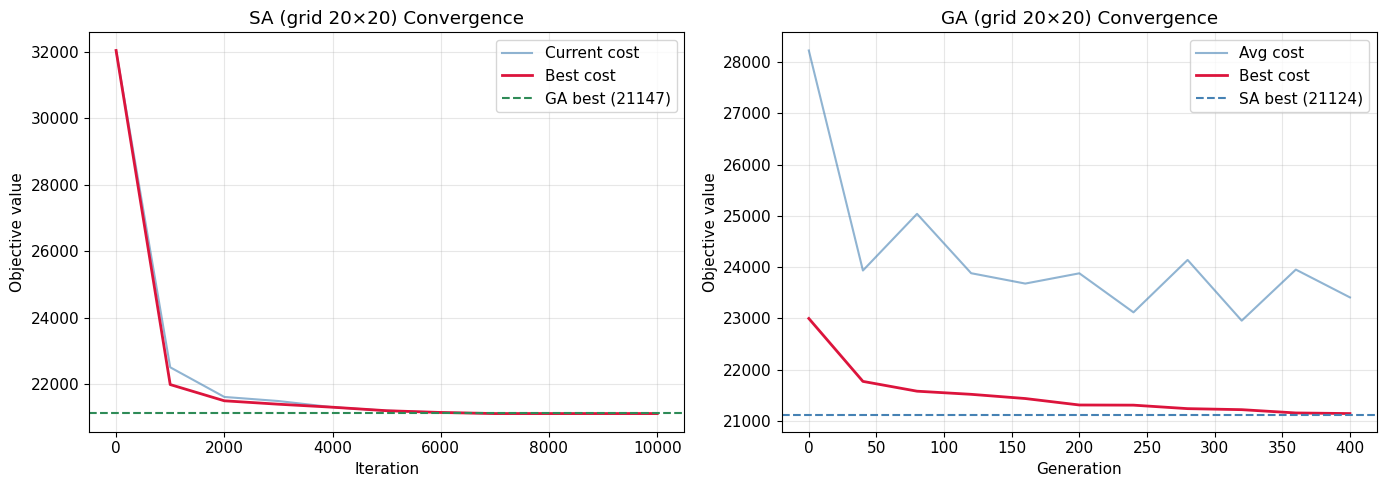

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_convergence_history(sa_hist_g, algo_name='SA (grid 20×20)', ax=axes[0])
plot_convergence_history(ga_hist_g, algo_name='GA (grid 20×20)', ax=axes[1])

# Draw the other algorithm's best as a reference
axes[0].axhline(ga_cost_g, color='seagreen', lw=1.5, ls='--', label=f'GA best ({ga_cost_g:.0f})')
axes[0].legend()
axes[1].axhline(sa_cost_g, color='steelblue', lw=1.5, ls='--', label=f'SA best ({sa_cost_g:.0f})')
axes[1].legend()

plt.tight_layout()
plt.show()

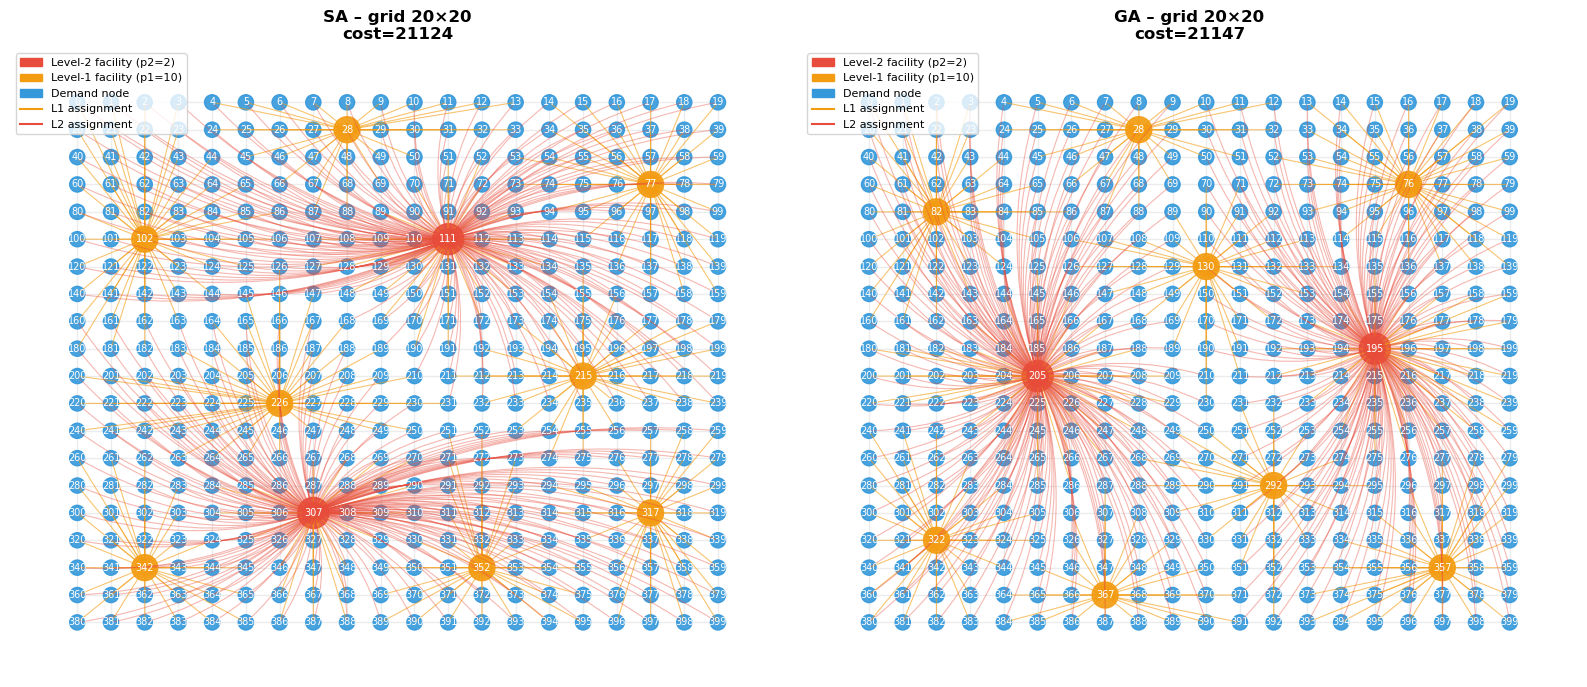

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_solution(inst_grid, sa_lv1_g, sa_lv2_g,
              title=f'SA – grid 20×20\ncost={sa_cost_g:.0f}', ax=axes[0])
plot_solution(inst_grid, ga_lv1_g, ga_lv2_g,
              title=f'GA – grid 20×20\ncost={ga_cost_g:.0f}', ax=axes[1])
plt.tight_layout()
plt.show()

# Tests on Veneto Graph

This section tests the hierarchical facility location problem (HFLP) algorithms on the Veneto municipalities network.

### Run Settings and import data

In [16]:
# ============================================================================
# CONFIGURATION CELL - Modify these settings as needed
# ============================================================================

# HFLP Problem Parameters
NUM_L1_LOCATIONS = 21      # Number of Level-1 (lower) facilities to open
NUM_L2_LOCATIONS = 5      # Number of Level-2 (upper) facilities (must be <= NUM_L1_LOCATIONS)

# ILP Solver Settings
ILP_TIME_LIMIT = 1000       # Timeout for ILP solver in seconds
ILP_VERBOSE = False       # Print ILP solver output

# Metaheuristic Settings
SA_SEED = 42
SA_MAX_ITER = 100_000
SA_T_INIT = 1000.0

GA_SEED = 42
GA_MAX_GEN = 2000
GA_POP_SIZE = 200

# Data paths
from pathlib import Path
WORK_DIR = Path("..")
COMUNI_CSV = WORK_DIR / "veneto-network/data/processed/comuni_veneto.csv"
POPOLAZIONE_CSV = WORK_DIR / "veneto-network/data/popolazione_2021.csv"
DISTANCES_CSV = WORK_DIR / "veneto-network/data/processed/distanze_comuni.csv"

print(f"Configuration set:")
print(f"  Level-1 facilities (p1): {NUM_L1_LOCATIONS}")
print(f"  Level-2 facilities (p2): {NUM_L2_LOCATIONS}")
print(f"  ILP timeout: {ILP_TIME_LIMIT}s")

Configuration set:
  Level-1 facilities (p1): 21
  Level-2 facilities (p2): 5
  ILP timeout: 1000s


In [17]:
import pandas as pd
comuni_df = pd.read_csv(COMUNI_CSV).set_index("codice_istat")
popolazioni_df = pd.read_csv(POPOLAZIONE_CSV).set_index("pro_com_t").rename(columns={"pop_res_21":"pop"})

comuni_df = comuni_df.join(popolazioni_df).reset_index()

print(f"Loaded {len(comuni_df)} comuni from Veneto")
comuni_df.sample(5, random_state=0)

Loaded 559 comuni from Veneto


,codice_istat,nome_comune,lat,lon,pop
504,28095,Urbana,45.200435,11.430243,2070
408,23070,San Giovanni Ilarione,45.526742,11.239101,4889
66,24017,Brogliano,45.589415,11.332404,3998
338,26096,Pieve del Grappa,45.856551,11.830637,6516
233,24050,Lastebasse,45.895687,11.288914,184


In [18]:
# Load distance matrix
distances_df = pd.read_csv(DISTANCES_CSV, index_col=0)
print(f"\nDistance matrix shape: {distances_df.shape}")
print(f"Distance matrix loaded (sparse storage with ~{distances_df.size} entries)")


Distance matrix shape: (560, 560)
Distance matrix loaded (sparse storage with ~313600 entries)


In [19]:
sus = list(set(distances_df.index[np.argmax(distances_df, axis=0)]))

mask = (comuni_df["codice_istat"] == 0)
for s in sus:
    mask |= (comuni_df["codice_istat"] == s)
comuni_df[mask]

,codice_istat,nome_comune,lat,lon,pop
105,23020,Castagnaro,45.092799,11.406736,3630


In [20]:
sus_codice_istat = [27028] # Pianiga per qualche motivo non ha distanze finite

distances_df.drop(sus_codice_istat, inplace=True, axis=0)
distances_df.drop(map(str,sus_codice_istat), inplace=True, axis=1)

In [21]:
# Create graph from distance matrix
import networkx as nx

n_nodes = len(comuni_df)
G = nx.Graph()
G.add_nodes_from(range(n_nodes))

# Create a mapping from node index to comune name and ISTAT code
node_to_name = {i: row['nome_comune'] for i, row in comuni_df.iterrows()}
node_to_istat = {i: row['codice_istat'] for i, row in comuni_df.iterrows()}
node_to_coords = {i: (row['lon'], row['lat']) for i, row in comuni_df.iterrows()}

# Set node attributes
nx.set_node_attributes(G, node_to_name, 'name')
nx.set_node_attributes(G, node_to_istat, 'istat')
nx.set_node_attributes(G, node_to_coords, 'pos')

# Create edges from distance matrix (using a threshold to avoid complete graph)
# We'll connect each node to its k nearest neighbors
k_neighbors  = 100

for i in range(k_neighbors):
    distances = distances_df.iloc[i].values
    # Find k nearest (excluding self)
    nearest_indices = np.argsort(distances)[1:k_neighbors+1]
    for j in nearest_indices:
        weight = distances[j]
        if not np.isnan(weight) and not np.isinf(weight):
            G.add_edge(i, j, weight=weight)

print(f"Graph created:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Connected: {nx.is_connected(G)}")

Graph created:
  Nodes: 559
  Edges: 9262
  Connected: True


In [22]:
dist_matrix = distances_df.values.astype(float)
dist_matrix = ( dist_matrix + dist_matrix.T) / 2

assert np.all(np.isfinite(dist_matrix))
assert np.all(~np.isnan(dist_matrix))

nodes = list(range(n_nodes))

# Create random demand vector
demand = comuni_df["pop"].to_numpy()

# Manually construct instance dict
inst = {
    "G": G,
    "nodes": nodes,
    "n": n_nodes,
    "dist": dist_matrix,
    "demand": demand,
    "p1": NUM_L1_LOCATIONS,
    "p2": NUM_L2_LOCATIONS,
}

print(f"HFLP Instance created:")
print(f"  n (total nodes): {inst['n']}")
print(f"  p1 (L1 facilities): {inst['p1']}")
print(f"  p2 (L2 facilities): {inst['p2']}")
print(f"  Total demand: {inst['demand'].sum():.1f}")

HFLP Instance created:
  n (total nodes): 559
  p1 (L1 facilities): 21
  p2 (L2 facilities): 5
  Total demand: 4840189.0


### Running solvers 

In [23]:
print("Solving with ILP solver (timeout: {}s)...".format(ILP_TIME_LIMIT))

ilp_lv1, ilp_lv2, ilp_cost, ilp_time, ilp_status = hflp.solve_hflp_ilp(
    inst, 
    time_limit=ILP_TIME_LIMIT,
    verbose=ILP_VERBOSE
)

print(f"\nILP Results:")
print(f"  Status: {ilp_status}")
print(f"  Objective value: {ilp_cost:.2f}")
print(f"  Solve time: {ilp_time:.2f}s")
print(f"  L1 facilities opened: {len(ilp_lv1)}")
print(f"  L2 facilities opened: {len(ilp_lv2)}")

Solving with ILP solver (timeout: 1000s)...

ILP Results:
  Status: Optimal
  Objective value: 51373478359.85
  Solve time: 71.88s
  L1 facilities opened: 21
  L2 facilities opened: 5


In [24]:
print(f"Solving with Simulated Annealing...")

sa_lv1, sa_lv2, sa_cost, sa_history = hflp.simulated_annealing_hflp(
    inst,
    T_init=SA_T_INIT,
    T_min=1e-3,
    alpha=0.9999,
    max_iter=SA_MAX_ITER,
    seed=SA_SEED,
    verbose=False
)

print(f"\nSimulated Annealing Results:")
print(f"  Objective value: {sa_cost:.2f}")
print(f"  L1 facilities opened: {len(sa_lv1)}")
print(f"  L2 facilities opened: {len(sa_lv2)}")

Solving with Simulated Annealing...

Simulated Annealing Results:
  Objective value: 51373478359.85
  L1 facilities opened: 21
  L2 facilities opened: 5


In [25]:
print(f"Solving HFLP with Genetic Algorithm...")

ga_lv1, ga_lv2, ga_cost, ga_history = hflp.genetic_algorithm_hflp(
    inst,
    pop_size=GA_POP_SIZE,
    max_gen=GA_MAX_GEN,
    tournament_k=4,
    crossover_prob=0.8,
    mutation_rate=0.4,
    elitism=True,
    seed=GA_SEED,
    verbose=False
)

print(f"\nGenetic Algorithm Results:")
print(f"  Objective value: {ga_cost:.2f}")
print(f"  L1 facilities opened: {len(ga_lv1)}")
print(f"  L2 facilities opened: {len(ga_lv2)}")

Solving HFLP with Genetic Algorithm...

Genetic Algorithm Results:
  Objective value: 52431259113.89
  L1 facilities opened: 21
  L2 facilities opened: 5


### Solution Comparison

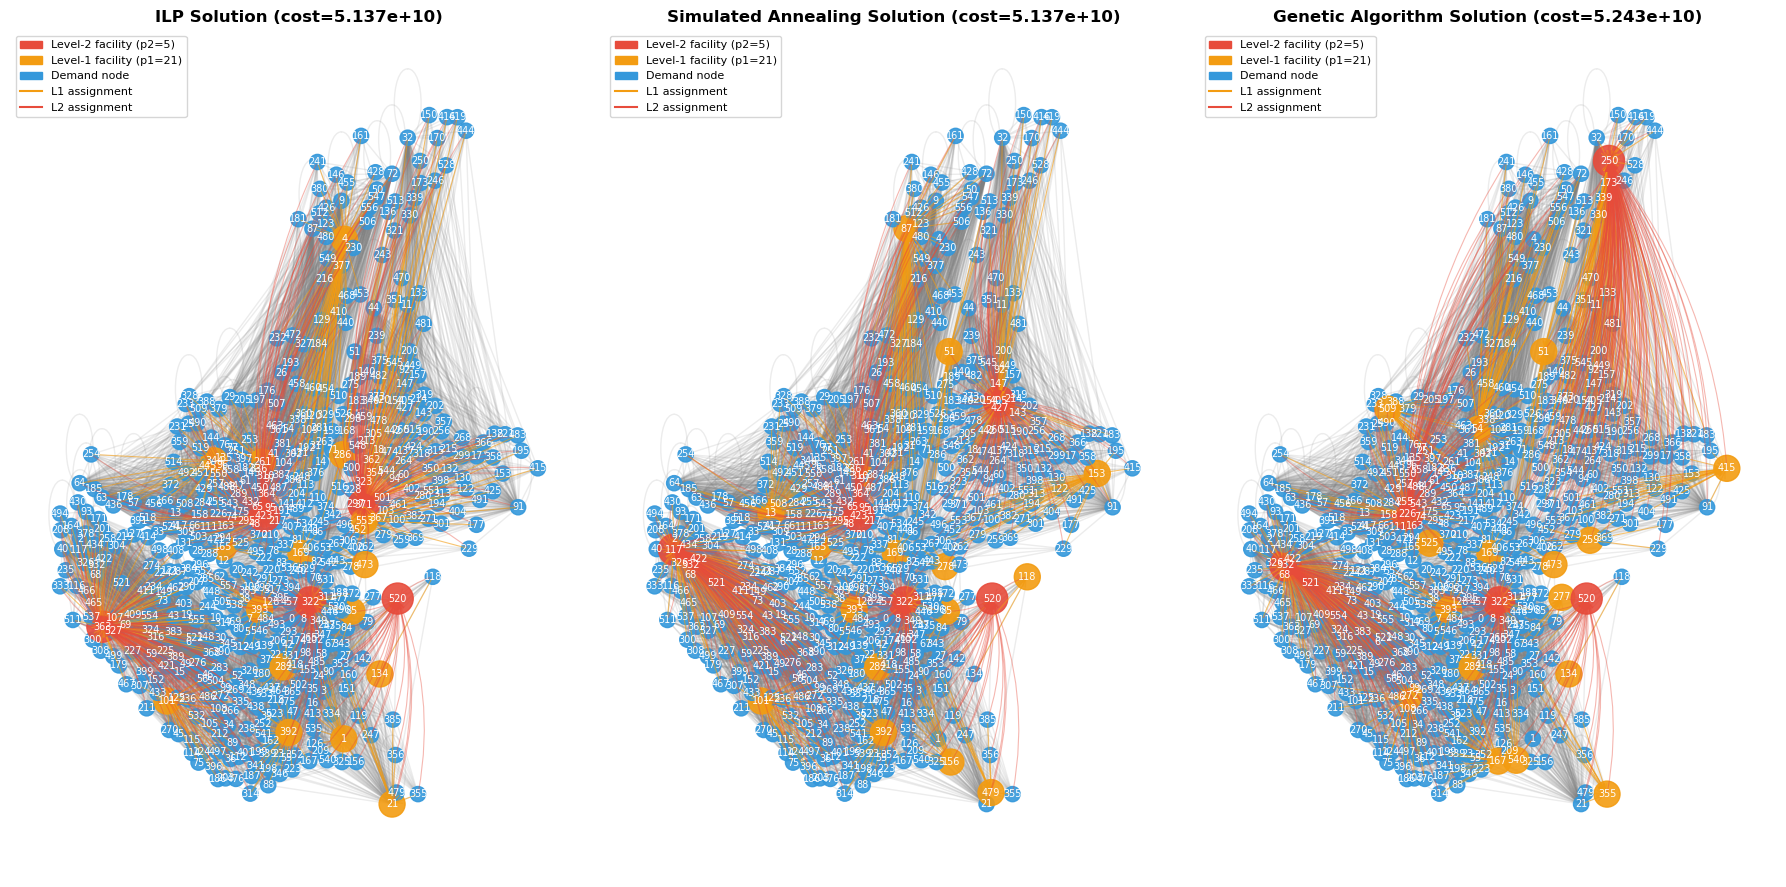

ILP solution graph plotted.


In [26]:
fig, ax = plt.subplots(1, 3, figsize=(18, 9))
hflp.plot_solution(inst, ilp_lv1, ilp_lv2, 
                    title=f"ILP Solution (cost={ilp_cost:.3e})", 
                    ax=ax[0])
hflp.plot_solution(inst, sa_lv1, sa_lv2,
                    title=f"Simulated Annealing Solution (cost={sa_cost:.3e})",
                    ax=ax[1])
hflp.plot_solution(inst, ga_lv1, ga_lv2,
                    title=f"Genetic Algorithm Solution (cost={ga_cost:.3e})",
                    ax=ax[2])
plt.tight_layout()
plt.show()

print("ILP solution graph plotted.")

In [27]:
# Comparison summary
comparison = pd.DataFrame({
    'Algorithm': ['ILP (Exact)', 'Simulated Annealing', 'Genetic Algorithm'],
    'Objective': [ilp_cost, sa_cost, ga_cost],
    'L1 Facilities': [len(ilp_lv1), len(sa_lv1), len(ga_lv1)],
    'L2 Facilities': [len(ilp_lv2), len(sa_lv2), len(ga_lv2)],
})

print("\n" + "="*70)
print("ALGORITHM COMPARISON")
print("="*70)
print(comparison.to_string(index=False))
print()

# Compute gap from best solution
best_cost = comparison['Objective'].min()
comparison['Gap from Best (%)'] = ((comparison['Objective'] - best_cost) / best_cost * 100).round(2)
print("\nGap from best solution:")
for idx, row in comparison.iterrows():
    print(f"  {row['Algorithm']}: {row['Gap from Best (%)']:.2f}%")


ALGORITHM COMPARISON
          Algorithm    Objective  L1 Facilities  L2 Facilities
        ILP (Exact) 5.137348e+10             21              5
Simulated Annealing 5.137348e+10             21              5
  Genetic Algorithm 5.243126e+10             21              5


Gap from best solution:
  ILP (Exact): 0.00%
  Simulated Annealing: 0.00%
  Genetic Algorithm: 2.06%


In [28]:
# Get the ILP Level-1 solution
best_l2_indices = ga_lv2
best_l2_names = [node_to_name[idx] for idx in sorted(best_l2_indices)]
best_l1_indices = ga_lv1
best_l1_names = [node_to_name[idx] for idx in sorted(best_l1_indices)]

print("="*70)
print("LEVEL-1 COMUNI (GA Solution)")
print("="*70)
print(f"\nTotal: {len(best_l1_names)} Level-1 facilities\n")
for i, name in enumerate(best_l1_names, 1):
    idx = sorted(best_l1_indices)[i-1]
    istat_code = node_to_istat[idx]
    demand_val = demand[idx]
    is_l2 = "(also L2)" if idx in best_l2_indices else ""
    print(f"  {i}. {name:25s} (ISTAT: {istat_code}, Demand: {demand_val:.0f}) {is_l2}")

LEVEL-1 COMUNI (GA Solution)

Total: 21 Level-1 facilities

  1. Borgo Valbelluna          (ISTAT: 25074, Demand: 13407) 
  2. Borso del Grappa          (ISTAT: 26004, Demand: 5890) 
  3. Chioggia                  (ISTAT: 27008, Demand: 48130) 
  4. Crespino                  (ISTAT: 29019, Demand: 1747) 
  5. Curtarolo                 (ISTAT: 28036, Demand: 7137) 
  6. Isola Vicentina           (ISTAT: 24048, Demand: 10197) (also L2)
  7. Lozzo di Cadore           (ISTAT: 25033, Demand: 1285) (also L2)
  8. Marcon                    (ISTAT: 27020, Demand: 17433) 
  9. Merlara                   (ISTAT: 28053, Demand: 2531) 
  10. Mira                      (ISTAT: 27023, Demand: 37974) 
  11. Monselice                 (ISTAT: 28055, Demand: 17363) 
  12. Padova                    (ISTAT: 28060, Demand: 208306) (also L2)
  13. Pescantina                (ISTAT: 23058, Demand: 17261) (also L2)
  14. Porto Tolle               (ISTAT: 29039, Demand: 9284) 
  15. Rovolon                   (IST